In [24]:
# ── 1. Imports ───────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Optional – comment out if not installed
try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except ImportError:
    HAS_WORDCLOUD = False
    print('WordCloud not installed — skipping cloud plots.')

try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False
    print('scikit-learn not installed — skipping TF-IDF.')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ Imports OK')

WordCloud not installed — skipping cloud plots.
scikit-learn not installed — skipping TF-IDF.
✅ Imports OK


In [25]:
# ── 2. Load & Merge Multiple CSV/XLS Files ────────────────────────────────────
import glob
import os

# 🔧 Lista os teus ficheiros aqui (CSV ou XLS/XLSX)
FILES = [
    'scopus.csv',
    'wos.xls',
    'ieee.csv',
    'acm.csv',
    'springer.xlsx',
]

# Alternativa: carrega todos os CSV/XLS da pasta automaticamente
FILES = glob.glob('*.csv') + glob.glob('*.xls') + glob.glob('*.xlsx')

def load_file(path):
    ext = os.path.splitext(path)[1].lower()
    if ext == '.csv':
        return pd.read_csv(path, encoding='utf-8', on_bad_lines='skip')
    elif ext in ('.xls', '.xlsx'):
        return pd.read_excel(path)
    else:
        raise ValueError(f'Formato não suportado: {ext}')

dfs = []
for f in FILES:
    try:
        tmp = load_file(f)
        tmp['_source_db'] = os.path.basename(f)   # marca a origem de cada paper
        dfs.append(tmp)
        #print(tmp.columns)
        print(f'✅ {f:30s} → {tmp.shape[0]} linhas, {tmp.shape[1]} colunas')
    except FileNotFoundError:
        print(f'⚠️  Ficheiro não encontrado: {f}')
    except Exception as e:
        print(f'❌ Erro ao carregar {f}: {e}')

# Concatena tudo
df_raw = pd.concat(dfs, ignore_index=True)

# ── Criar coluna unificada de Year ────────────────────────────────

print(f'\n📦 Total antes da deduplicação: {len(df_raw)} linhas')



# ── Deduplicação por DOI (apenas quando existe DOI válido) ───────────────

doi_col = next(
    (c for c in df_raw.columns
     if c.lower() in ['doi', 'digital object identifier']),
    None
)

if doi_col:

    # Limpeza DOI
    df_raw['_doi_clean'] = (
        df_raw[doi_col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # Converte valores inválidos para NA
    df_raw['_doi_clean'] = df_raw['_doi_clean'].replace(
        ['', 'nan', 'none', 'null'],
        pd.NA
    )

    before = len(df_raw)

    # Separa papers com DOI dos sem DOI
    with_doi = df_raw[df_raw['_doi_clean'].notna()]
    without_doi = df_raw[df_raw['_doi_clean'].isna()]

    # Deduplicação apenas nos que têm DOI
    with_doi = with_doi.drop_duplicates(
        subset='_doi_clean',
        keep='first'
    )

    # Junta novamente
    df_dedup = pd.concat(
        [with_doi, without_doi],
        ignore_index=True
    )

    removed_doi = before - len(df_dedup)

    print(f'🔁 Duplicados removidos por DOI: {removed_doi}')

else:
    df_dedup = df_raw.copy()
    print('⚠️ Coluna DOI não encontrada.')

✅ scopus.csv                     → 83 linhas, 12 colunas
✅ springer.csv                   → 250 linhas, 11 colunas
✅ ieee.csv                       → 390 linhas, 29 colunas
✅ acm.csv                        → 273 linhas, 12 colunas
✅ webofscience.csv               → 50 linhas, 73 colunas

📦 Total antes da deduplicação: 1046 linhas
🔁 Duplicados removidos por DOI: 63


In [26]:
# ── Criar coluna unificada de título ───────────────────────────────

possible_title_cols = [
    'title',
    'Title',
    'TI',
    'article title',
    'Article Title',
    'document title',
    'Document Title'
]

# Mantém apenas colunas existentes
existing_title_cols = [
    c for c in possible_title_cols
    if c in df_dedup.columns
]

print("Colunas de título encontradas:")
print(existing_title_cols)

# Cria coluna unificada
df_dedup['_merged_title'] = None

for col in existing_title_cols:
    df_dedup['_merged_title'] = (
        df_dedup['_merged_title']
        .fillna(df_dedup[col])
    )

# Limpeza
df_dedup['_title_clean'] = (
    df_dedup['_merged_title']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Remove títulos vazios/nan
df_dedup['_title_clean'] = df_dedup['_title_clean'].replace(
    ['', 'nan', 'none', 'null'],
    pd.NA
)

# ── Deduplicação por título ────────────────────────────────────────

before = len(df_dedup)

with_title = df_dedup[df_dedup['_title_clean'].notna()]
without_title = df_dedup[df_dedup['_title_clean'].isna()]

with_title = with_title.drop_duplicates(
    subset='_title_clean',
    keep='first'
)

df_dedup = pd.concat(
    [with_title, without_title],
    ignore_index=True
)

removed_title = before - len(df_dedup)

print(f'🔁 Duplicados removidos por Título: {removed_title}')
print(f'📄 Total após deduplicação: {len(df_dedup)}')

Colunas de título encontradas:
['title', 'Title', 'Article Title', 'Document Title']
🔁 Duplicados removidos por Título: 16
📄 Total após deduplicação: 967


In [27]:

df = df_dedup.copy()
print(f'\n✅ Total final após deduplicação: {len(df)} papers únicos')
print(f'\nDistribuição por base de dados:')
print(df['_source_db'].value_counts().to_string())

print(f'\nColunas encontradas:')
for c in df.columns:
    print(f'  {c!r}')

df.head(3)


✅ Total final após deduplicação: 967 papers únicos

Distribuição por base de dados:
_source_db
ieee.csv            349
acm.csv             261
springer.csv        250
scopus.csv           82
webofscience.csv     25

Colunas encontradas:
  'Title'
  'Takeaway'
  'Authors'
  'Year'
  'Citations'
  'Abstract'
  'Study Type'
  'Journal'
  'Journal SJR Quartile'
  'DOI'
  'Consensus Link'
  '_source_db'
  'Item Title'
  'Publication Title'
  'Book Series Title'
  'Journal Volume'
  'Journal Issue'
  'Item DOI'
  'URL'
  'Content Type'
  'Document Title'
  'Author Affiliations'
  'Date Added To Xplore'
  'Volume'
  'Issue'
  'Start Page'
  'End Page'
  'ISSN'
  'ISBNs'
  'Funding Information'
  'PDF Link'
  'Author Keywords'
  'IEEE Terms'
  'Mesh_Terms'
  'Article Citation Count'
  'Patent Citation Count'
  'Reference Count'
  'License'
  'Online Date'
  'Issue Date'
  'Meeting Date'
  'Publisher'
  'Document Identifier'
  'authors'
  'title'
  'venue'
  'pages'
  'article'
  'publisher_lo

,Title,Takeaway,Authors,Year,Citations,Abstract,Study Type,Journal,Journal SJR Quartile,DOI,...,Pubmed Id,Open Access Designations,Highly Cited Status,Hot Paper Status,Date of Export,UT (Unique WOS ID),Web of Science Record,_doi_clean,_merged_title,_title_clean
0,Zero-Shot Machine Unlearning,"Zero-shot machine unlearning, using error mini...","Vikram S Chundawat, A. Tarun, Murari Mandal, M...",2022.0,200.0,Modern privacy regulations grant citizens the ...,NaN,IEEE Transactions on Information Forensics and...,1.0,10.1109/tifs.2023.3265506,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.1109/tifs.2023.3265506,Zero-Shot Machine Unlearning,zero-shot machine unlearning
1,When Machine Unlearning Meets Retrieval-Augmen...,Our lightweight RAG-based unlearning framework...,"Shang Wang, Tianqing Zhu, Dayong Ye, Wanlei Zhou",2024.0,19.0,The deployment of large language models (LLMs)...,NaN,IEEE Transactions on Dependable and Secure Com...,1.0,10.1109/tdsc.2025.3620832,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.1109/tdsc.2025.3620832,When Machine Unlearning Meets Retrieval-Augmen...,when machine unlearning meets retrieval-augmen...
2,Machine Unlearning: A Survey,"Machine unlearning, a key technology for priva...","Heng Xu, Tianqing Zhu, Lefeng Zhang, Wanlei Zh...",2023.0,51.0,Machine learning has attracted widespread atte...,NaN,ACM Computing Surveys,1.0,10.1145/3603620,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.1145/3603620,Machine Unlearning: A Survey,machine unlearning: a survey


In [28]:
FIELD_ALIASES = {
    'year': [
        'Year',
        'year',
        'PY',
        'Publication Year',
        'publication year',
        'year_published',
        'Date',
        'PublicationDate'
    ],

    'title': [
        'Title',
        'title',
        'TI',
        'Article Title',
        'Document Title',
        'paper_title'
    ],

    'abstract': [
        'Abstract',
        'abstract',
        'AB',
        'Abstract Note',
        'Description'
    ],

    'authors': [
        'Authors',
        'authors',
        'AU',
        'Author',
        'Author Names',
        'author'
    ],

    'keywords': [
        'Author Keywords',
        'Keywords',
        'keywords',
        'DE',
        'ID',
        'Index Keywords',
        'keyword'
    ],

    'source': [
        'Source title',
        'Publication Title',
        'source',
        'SO',
        'Journal',
        'journal',
        'Booktitle',
        'Conference Name',
        'venue'
    ],

    'citations': [
        'Cited by',
        'TC',
        'Times Cited',
        'citation_count',
        'Citations',
        'cited_by',
        'Article Citation Count'
    ],

    'doi': [
        'DOI',
        'doi',
        'Digital Object Identifier'
    ],

    'type': [
        'Document Type',
        'Item Type',
        'type',
        'doctype',
        'Document Identifier'
    ],
}

# normalização mais robusta
df_columns_norm = {
    c.strip().lower().replace('_', ' '): c
    for c in df.columns
}

col_map = {}

for std_name, aliases in FIELD_ALIASES.items():

    for alias in aliases:

        alias_norm = alias.strip().lower().replace('_', ' ')

        if alias_norm in df_columns_norm:
            col_map[std_name] = df_columns_norm[alias_norm]
            break

print("Column mapping resolved:")

for k, v in col_map.items():
    print(f"{k:12s} -> {v}")

missing = [k for k in FIELD_ALIASES if k not in col_map]

if missing:
    print("\nMissing fields:", missing)

# fallback seguro para YEAR
if 'year' not in col_map:

    possible = [
        c for c in df.columns
        if 'year' in c.lower()
        or 'date' in c.lower()
    ]

    if possible:
        col_map['year'] = possible[0]
        print(f"Fallback year column: {col_map['year']}")
    else:
        raise ValueError("No year/date column found")

Column mapping resolved:
year         -> Year
title        -> title
abstract     -> Abstract
authors      -> authors
keywords     -> Author Keywords
source       -> Source Title
citations    -> Citations
doi          -> doi
type         -> Document Type


In [29]:
# ── 4. Basic Data Quality ─────────────────────────────────────────────────────
print('=== Missing Values ===')
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
summary = pd.DataFrame({'missing': miss, '%': miss_pct})
display(summary[summary['missing'] > 0].sort_values('%', ascending=False))

# Year cleaning
if 'year' in col_map:
    df['_year'] = pd.to_numeric(df[col_map['year']], errors='coerce')
    print(f"\nYear range: {int(df['_year'].min())} – {int(df['_year'].max())}")
    print(f"Records with valid year: {df['_year'].notna().sum()} / {len(df)}")

# Citations cleaning
if 'citations' in col_map:
    df['_citations'] = pd.to_numeric(df[col_map['citations']], errors='coerce').fillna(0).astype(int)

print(f"\nTotal papers: {len(df)}")




=== Missing Values ===


,missing,%
Book Author Full Names,967,100.0
Cited References,967,100.0
Book DOI,967,100.0
Supplement,967,100.0
Part Number,967,100.0
...,...,...
Publication Title,368,38.1
_merged_title,286,29.6
_title_clean,286,29.6
Authors,273,28.2



Year range: 1986 – 2026
Records with valid year: 931 / 967

Total papers: 967


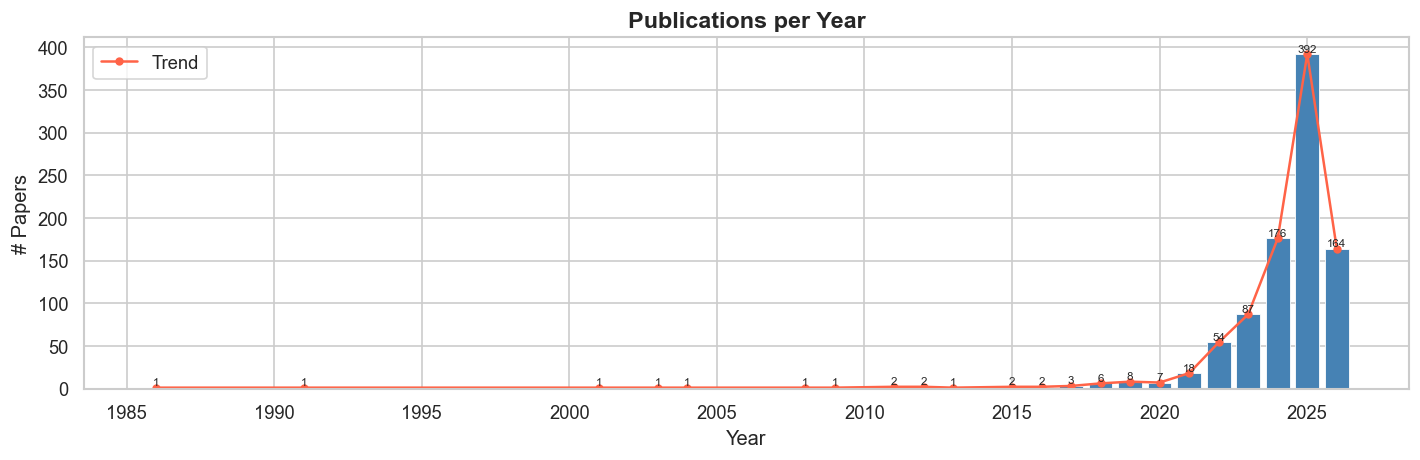

_year
1986      1
1991      1
2001      1
2003      1
2004      1
2008      1
2009      1
2011      2
2012      2
2013      1
2015      2
2016      2
2017      3
2018      6
2019      8
2020      7
2021     18
2022     54
2023     87
2024    176
2025    392
2026    164


In [30]:
# ── 5. Publications Per Year ──────────────────────────────────────────────────
if 'year' not in col_map:
    print('Year column not found — skipping temporal analysis.')
else:
    year_counts = df['_year'].dropna().astype(int).value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(12, 4))
    bars = ax.bar(year_counts.index, year_counts.values, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.plot(year_counts.index, year_counts.values, marker='o', color='tomato', linewidth=1.5, markersize=4, label='Trend')

    # Annotate bars
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, str(int(h)),
                    ha='center', va='bottom', fontsize=7)

    ax.set_title('Publications per Year', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('# Papers')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig_publications_per_year.png', bbox_inches='tight')
    plt.show()
    print(year_counts.to_string())

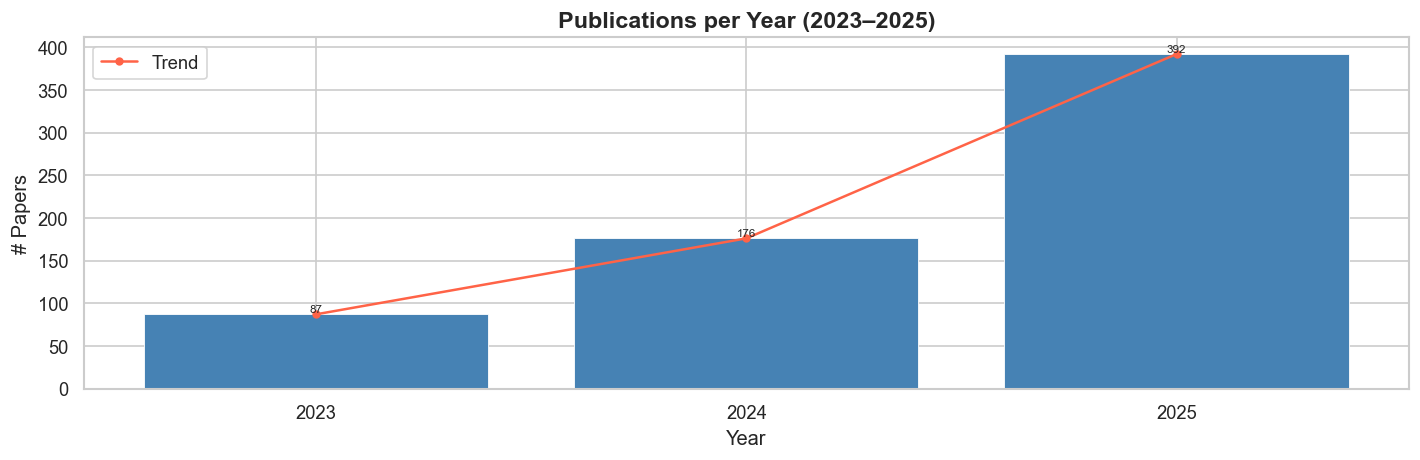

_year
2023     87
2024    176
2025    392


In [31]:
# ── 5. Publications Per Year ──────────────────────────────────────────────────
if 'year' not in col_map:
    print('Year column not found — skipping temporal analysis.')
else:
    year_counts = (
        df['_year']
        .dropna()
        .astype(int)
    )

    # manter apenas anos entre 2023 e 2025
    year_counts = year_counts[(year_counts >= 2023) & (year_counts <= 2025)]

    # contar publicações por ano
    year_counts = year_counts.value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(12, 4))

    bars = ax.bar(
        year_counts.index,
        year_counts.values,
        color='steelblue',
        edgecolor='white',
        linewidth=0.5
    )

    ax.plot(
        year_counts.index,
        year_counts.values,
        marker='o',
        color='tomato',
        linewidth=1.5,
        markersize=4,
        label='Trend'
    )

    # anotar barras
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                h + 0.3,
                str(int(h)),
                ha='center',
                va='bottom',
                fontsize=7
            )

    ax.set_title('Publications per Year (2023–2025)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('# Papers')

    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    ax.legend()

    plt.tight_layout()

    plt.savefig('fig_publications_per_year.png', bbox_inches='tight')

    plt.show()

    print(year_counts.to_string())

In [32]:
df.to_csv('final_base.csv', index=False, encoding="utf-8")
